In [1]:

import sys
print(sys.executable) # proves the venv is used

/Users/rajonkar/Documents/MyLearning/.venv/bin/python


In [6]:
# %pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [4]:
# %pip install prophet

In [4]:
from tqdm.autonotebook import tqdm as notebook_tqdm

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import prophet
from prophet import Prophet

In [6]:
path='/Users/rajonkar/Documents/MyLearning/Ex_Files_Python_Data_Analysis_Healthcare/Exercise Files/Demo Pharmacy Sales Data.csv'

df_pharmacy_sales = pd.read_csv(path)

In [9]:
# df_pharmacy_sales = pd.read_csv('/content/demo_pharmacy_sales_data.csv')
# df_pharmacy_sales

In [10]:
df_pharmacy_sales[df_pharmacy_sales['Med_class'].str.contains('Anxiolytic')][['Date Sold', 'Quantity Sold']]

,Date Sold,Quantity Sold
3,2021-02-19,89
122,2022-03-01,82
143,2020-08-11,17
327,2020-12-08,86
518,2019-03-31,70
...,...,...
999594,2019-08-11,42
999711,2020-05-16,71
999772,2019-09-02,63
999883,2019-09-09,38


In [11]:
df_prophet = df_pharmacy_sales[df_pharmacy_sales['Med_class'].str.contains('Anxiolytic')][['Date Sold', 'Quantity Sold']]

In [12]:
df_prophet = df_prophet.reset_index()
df_prophet

,index,Date Sold,Quantity Sold
0,3,2021-02-19,89
1,122,2022-03-01,82
2,143,2020-08-11,17
3,327,2020-12-08,86
4,518,2019-03-31,70
...,...,...,...
9999,999594,2019-08-11,42
10000,999711,2020-05-16,71
10001,999772,2019-09-02,63
10002,999883,2019-09-09,38


In [13]:
df_prophet.dtypes

index            int64
Date Sold          str
Quantity Sold    int64
dtype: object

In [14]:
df_prophet = df_prophet.rename(columns={'Date Sold': 'ds','Quantity Sold':'y'})
df_prophet

,index,ds,y
0,3,2021-02-19,89
1,122,2022-03-01,82
2,143,2020-08-11,17
3,327,2020-12-08,86
4,518,2019-03-31,70
...,...,...,...
9999,999594,2019-08-11,42
10000,999711,2020-05-16,71
10001,999772,2019-09-02,63
10002,999883,2019-09-09,38


In [15]:
type(df_prophet['ds'][0])

str

In [16]:
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

In [17]:
type(df_prophet['ds'][0])

pandas.Timestamp

In [18]:
model = Prophet()

In [19]:
model.fit(df_prophet)

14:56:01 - cmdstanpy - INFO - Chain [1] start processing
14:56:02 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

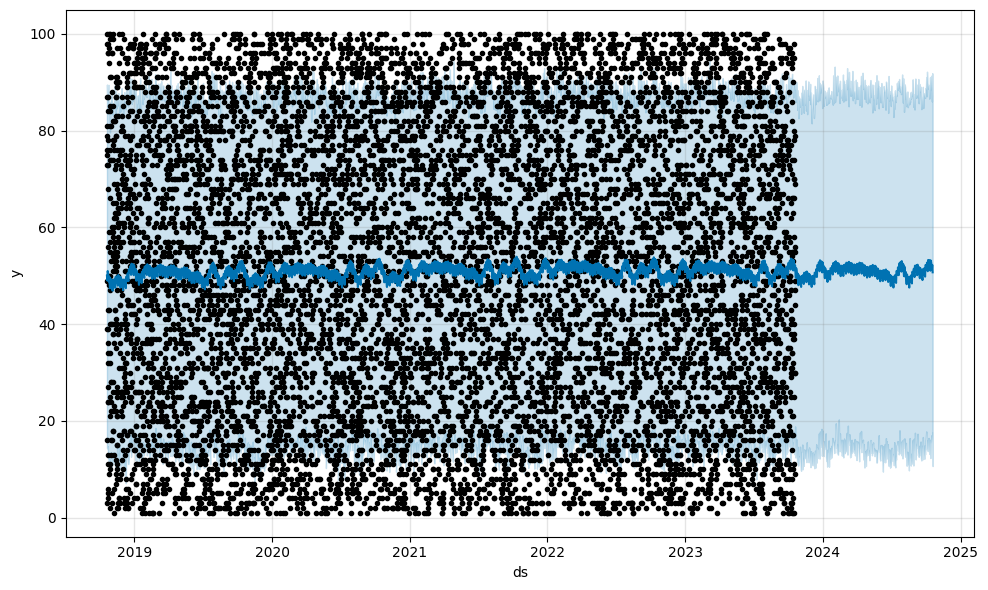

In [22]:
fig = model.plot(forecast)
plt.show()

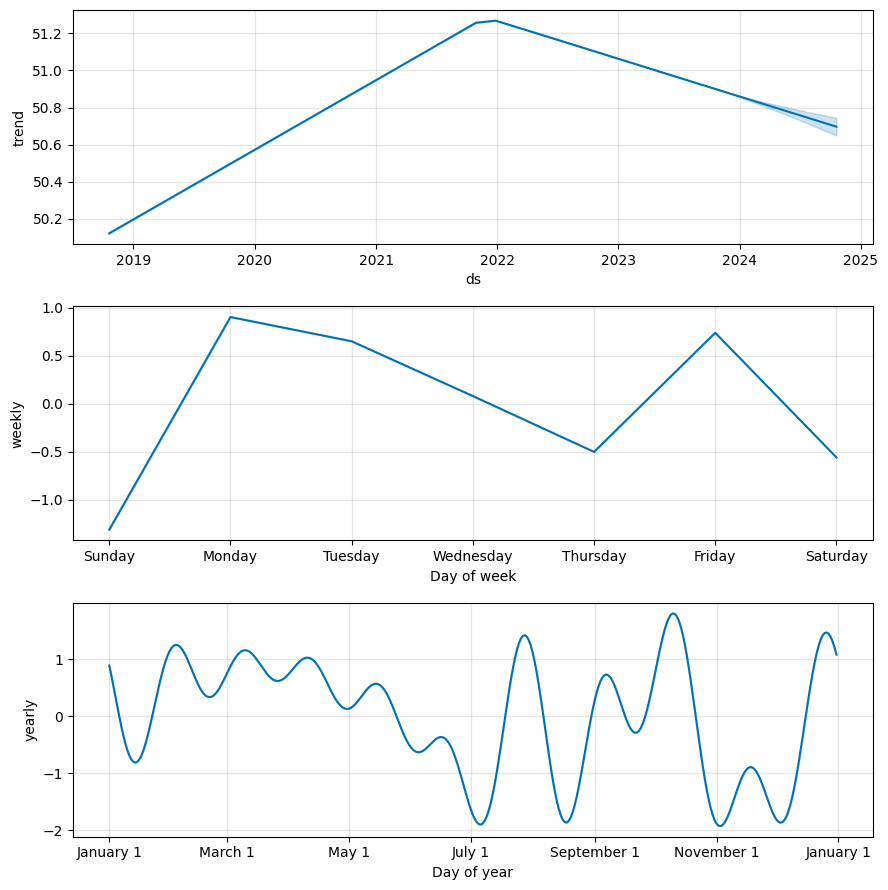

In [23]:
fig = model.plot_components(forecast)
plt.show()